## ERA5 -> PRISM downscaling: analysis

Companion analysis notebook for the CLI runs. It checks the aligned data, reloads saved checkpoints, and keeps the main RMSE/error-map notes in one place.

Expected local files: `data_raw/`, `checkpoints/`, and `results/` from the repo scripts.



In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
ROOT = None
for p in (_cwd, *_cwd.parents):
    if (p / "datasets").exists() and (p / "models").exists() and (p / "training").exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError(f"Could not find repo root from cwd={_cwd}")

sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch

from datasets.prism_dataset import ERA5_PRISM_Dataset
from models.baselines import upsample_latest_era5
from models.cnn_downscaler import CNNDownscaler
from models.convlstm_downscaler import ConvLSTMDownscaler

ERA5_PATH = ROOT / "data_raw" / "era5_georgia_multi.nc"
PRISM_PATH = ROOT / "data_raw" / "prism"
EVAL_DIR = ROOT / "results" / "evaluation"

# Prefer checkpoints produced by the controlled experiment runner.
BEST_EXP = ROOT / "results" / "experiments" / "core4_h3"
CNN_CKPT = BEST_EXP / "checkpoints" / "cnn_best.pt"
CONVLSTM_CKPT = BEST_EXP / "checkpoints" / "convlstm_best.pt"

if not CNN_CKPT.exists() or not CONVLSTM_CKPT.exists():
    raise FileNotFoundError(
        "Missing expected best experiment checkpoints under results/experiments/core4_h3/. "
        "Run: .venv/bin/python scripts/run_core_experiments.py --input-sets t2m core4 --histories 1 3 6 --overwrite"
    )

DEVICE = torch.device("cpu")


def load_checkpoint_model(model_name: str, ckpt_path: Path) -> tuple[torch.nn.Module, dict]:
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    cfg = ckpt.get("model_config", {})
    if model_name == "cnn":
        model = CNNDownscaler(
            in_channels=int(cfg["in_channels"]),
            out_channels=int(cfg.get("out_channels", 1)),
            base_channels=int(cfg.get("base_channels", 32)),
        )
    elif model_name == "convlstm":
        model = ConvLSTMDownscaler(
            input_channels=int(cfg.get("input_channels", 1)),
            hidden_channels=int(cfg.get("hidden_channels", 32)),
            out_channels=int(cfg.get("out_channels", 1)),
            kernel_size=int(cfg.get("kernel_size", 3)),
        )
    else:
        raise ValueError(model_name)

    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE).eval()
    return model, ckpt


In [2]:

ds = ERA5_PRISM_Dataset(
    era5_path=str(ERA5_PATH),
    prism_path=str(PRISM_PATH),
    history_length=3,
    input_set='t2m',
    verbose=False,
)

x, y = ds[0]
print('X', tuple(x.shape), 'Y', tuple(y.shape), 'date', ds.metadata(0).date.strftime('%Y-%m-%d'))
assert torch.isfinite(x).all() and torch.isfinite(y).all()


X (3, 1, 21, 21) Y (1, 121, 121) date 2023-01-03


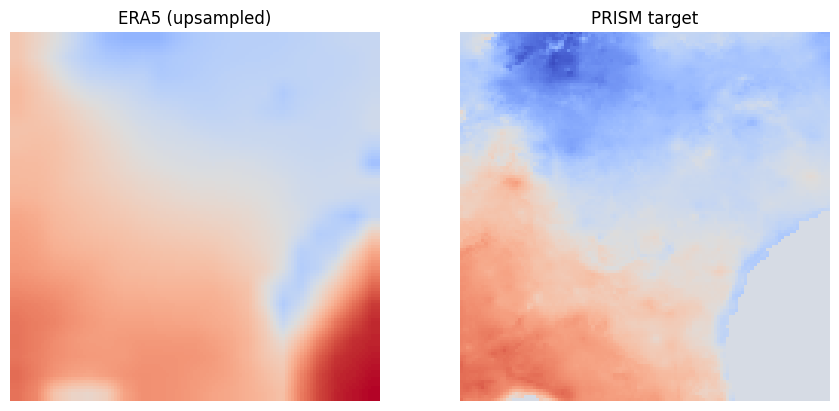

In [3]:
import matplotlib.pyplot as plt

# Visualize: upsampled ERA5 baseline vs PRISM target
xb = x.unsqueeze(0)
yb = y.unsqueeze(0)
era5_up = upsample_latest_era5(xb, target_size=(yb.shape[-2], yb.shape[-1])).squeeze().cpu().numpy()
prism = yb.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
vmin = float(min(np.min(era5_up), np.min(prism)))
vmax = float(max(np.max(era5_up), np.max(prism)))
axes[0].imshow(era5_up, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0].set_title('ERA5 (upsampled)')
axes[0].axis('off')
axes[1].imshow(prism, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[1].set_title('PRISM target')
axes[1].axis('off')
plt.show()


In [4]:
# Load models and run a single-sample prediction.

cnn, cnn_ckpt = load_checkpoint_model('cnn', CNN_CKPT)
convlstm, conv_ckpt = load_checkpoint_model('convlstm', CONVLSTM_CKPT)

# Use the train-split normalization stored in the checkpoint.
cnn_mean = torch.tensor(cnn_ckpt['input_norm']['mean'], device=DEVICE).view(1, 1, -1, 1, 1)
cnn_std = torch.tensor(cnn_ckpt['input_norm']['std'], device=DEVICE).view(1, 1, -1, 1, 1).clamp(min=1e-6)

cl_mean = torch.tensor(conv_ckpt['input_norm']['mean'], device=DEVICE).view(1, 1, -1, 1, 1)
cl_std = torch.tensor(conv_ckpt['input_norm']['std'], device=DEVICE).view(1, 1, -1, 1, 1).clamp(min=1e-6)

xb = x.unsqueeze(0).to(DEVICE)
yb = y.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    cnn_pred = cnn((xb - cnn_mean) / cnn_std, target_size=(yb.shape[-2], yb.shape[-1]))
    cl_pred = convlstm((xb - cl_mean) / cl_std, target_size=(yb.shape[-2], yb.shape[-1]))

cnn_pred_np = cnn_pred.squeeze().cpu().numpy()
cl_pred_np = cl_pred.squeeze().cpu().numpy()
target_np = yb.squeeze().cpu().numpy()

assert np.isfinite(cnn_pred_np).all() and np.isfinite(cl_pred_np).all()


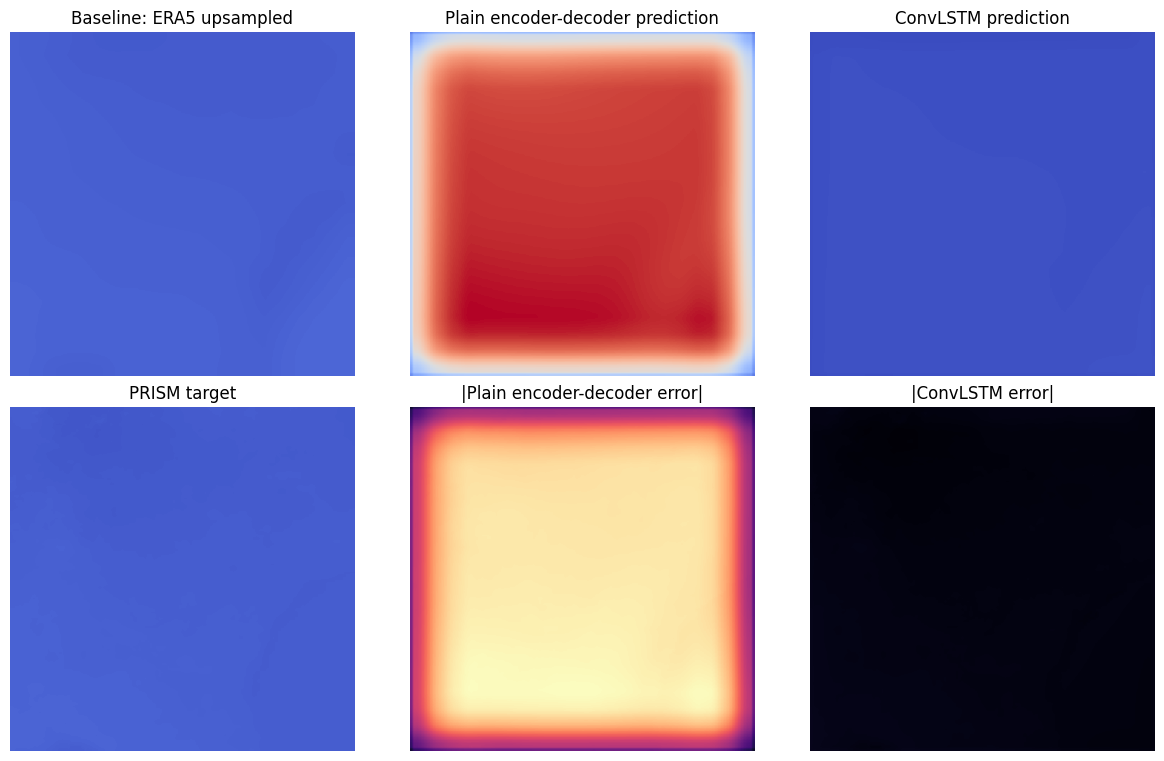

In [5]:
# Compare baselines vs models on a single example.

abs_err_cnn = np.abs(cnn_pred_np - target_np)
abs_err_cl = np.abs(cl_pred_np - target_np)

fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), constrained_layout=True)

# Row 1: fields
vmin = float(min(np.min(era5_up), np.min(cnn_pred_np), np.min(cl_pred_np), np.min(target_np)))
vmax = float(max(np.max(era5_up), np.max(cnn_pred_np), np.max(cl_pred_np), np.max(target_np)))

axes[0, 0].imshow(era5_up, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Baseline: ERA5 upsampled')
axes[0, 0].axis('off')

axes[0, 1].imshow(cnn_pred_np, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('Plain encoder-decoder prediction')
axes[0, 1].axis('off')

axes[0, 2].imshow(cl_pred_np, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0, 2].set_title('ConvLSTM prediction')
axes[0, 2].axis('off')

# Row 2: errors + target
err_max = float(max(np.max(abs_err_cnn), np.max(abs_err_cl)))
axes[1, 0].imshow(target_np, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[1, 0].set_title('PRISM target')
axes[1, 0].axis('off')

axes[1, 1].imshow(abs_err_cnn, cmap='magma', vmin=0.0, vmax=err_max)
axes[1, 1].set_title('|Plain encoder-decoder error|')
axes[1, 1].axis('off')

axes[1, 2].imshow(abs_err_cl, cmap='magma', vmin=0.0, vmax=err_max)
axes[1, 2].set_title('|ConvLSTM error|')
axes[1, 2].axis('off')

plt.show()


In [6]:
# Metrics table from the latest evaluation output.

csv_path = EVAL_DIR / 'baselines_summary.csv'
if not csv_path.exists():
    raise FileNotFoundError(f"Missing {csv_path}. Run evaluation/evaluate_model.py first.")

df = pd.read_csv(csv_path)
df = df[['model', 'rmse', 'mae', 'bias', 'correlation']].sort_values('rmse')
df


,model,rmse,mae,bias,correlation
0,convlstm,11.422297,11.337112,-11.334647,0.635297


## Short observations

- Persistence is a strong baseline for daily temperature because the latest ERA5 `t2m` field already carries much of the large-scale signal.
- ConvLSTM can beat persistence, but only for some history/input choices on the small split.
- The plain encoder-decoder (`cnn`) is mostly weak on the small sweep; `core4_h6` is the local exception in `results/experiments/summary.csv`.



## Notes

- The plain encoder-decoder treats history as stacked channels; ConvLSTM keeps the time axis explicit.
- Error maps show spatial structure, but high PRISM gradients are only a weak explanation for the residuals.
- The main open issue is still data coverage, not a missing large architecture.



In [7]:
# Experiment summary table (generated by scripts/run_core_experiments.py)

exp_summary = ROOT / 'results' / 'experiments' / 'summary.csv'
if exp_summary.exists():
    exp_df = pd.read_csv(exp_summary)
    exp_df
else:
    print(f"Missing {exp_summary}. Run scripts/run_core_experiments.py first.")


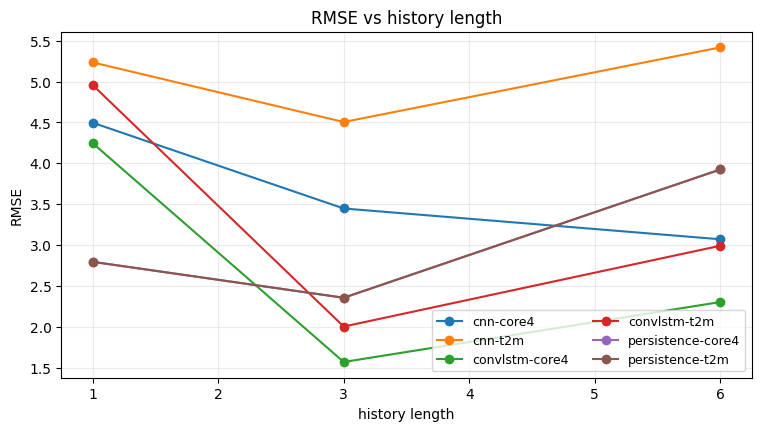

In [8]:
# RMSE vs history length (when summary.csv is available)

if 'exp_df' in globals() and isinstance(exp_df, pd.DataFrame) and not exp_df.empty:
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.2), constrained_layout=True)
    for (model, input_set), grp in exp_df.groupby(['model', 'input_set']):
        if model not in ('cnn', 'convlstm', 'persistence'):
            continue
        g = grp.sort_values('history')
        ax.plot(g['history'], g['rmse'], marker='o', label=f"{model}-{input_set}")
    ax.set_xlabel('history length')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE vs history length')
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=9)
    plt.show()


## Final multi-variable comparison

Controlled grid from `results/experiments/summary.csv` using `data_raw/era5_georgia_multi.nc`.

Small-run readout:
- Best row: **ConvLSTM, core4, history=3**.
- `core4` helps ConvLSTM at history 3.
- Gains are always measured against the matching persistence baseline.



In [9]:
# Build a compact comparison table from results/experiments/summary.csv

exp_summary = ROOT / "results" / "experiments" / "summary.csv"
if not exp_summary.exists():
    raise FileNotFoundError(f"Missing {exp_summary}. Run scripts/run_core_experiments.py first.")

exp_df = pd.read_csv(exp_summary)

# Keep a small set of rows that answer the core question.
keep = exp_df[
    exp_df["model"].isin(["persistence", "convlstm"]) & exp_df["history"].isin([1, 3, 6]) & exp_df["input_set"].isin(["t2m", "core4"])
].copy()

pivot = keep.pivot_table(
    index=["history"],
    columns=["model", "input_set"],
    values="rmse",
    aggfunc="first",
).sort_index()

pivot

model      convlstm           persistence          
input_set     core4       t2m       core4       t2m
history                                            
1          4.246121  4.956882    2.795166  2.795166
3          1.570430  2.003678    2.355815  2.355815
6          2.303556  2.991683    3.924166  3.924166

### Comparison table (t2m vs core4)

Derived directly from `results/experiments/summary.csv`.

- Best small-run row is **ConvLSTM, core4, history=3** with RMSE **1.57**.
- At history 3, `core4` improves ConvLSTM RMSE over `t2m` (**1.57** vs **2.00**).
- History 6 does not improve on history 3 for ConvLSTM.
- The plain encoder-decoder (`cnn`) is mostly worse than persistence on the small grid; `core4_h6` is the local exception.



## Error Analysis: Where the Model Fails

Controlled **ConvLSTM**, **core4**, **history=3** checkpoint. Metrics and figures are produced by:

`python scripts/spatial_error_analysis.py`

Read `docs/experiments/error_analysis.json` for numeric summaries.


correlation_gradient_error: 0.08117873328669341
mean_error: 1.1968088869668774 max_error: 10.428970336914062

There is a small positive association between mean gradient and mean absolute error (r=0.081 on per-pixel mean maps; pooled over all pixels and samples r=0.043). High-gradient areas contribute modestly but do not explain most error variance; other factors (temporal context, systematic bias, or small misalignments) remain important.


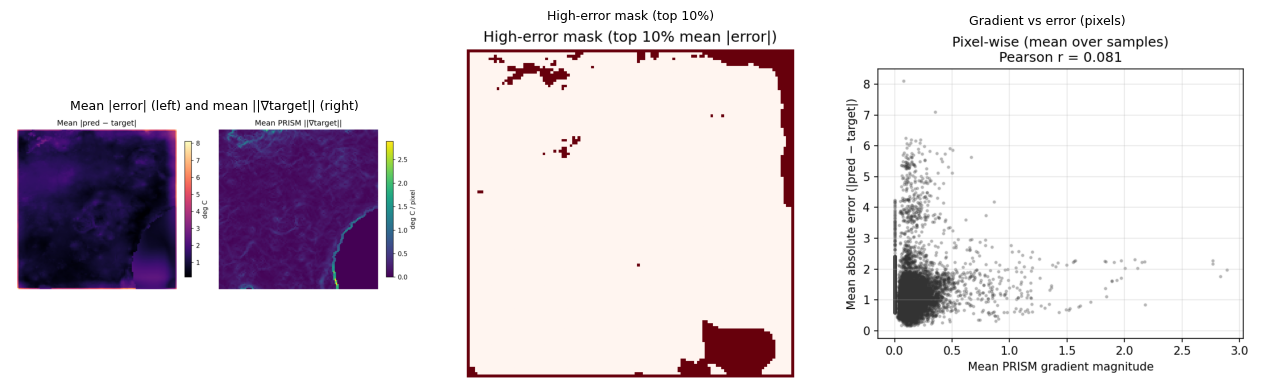

In [10]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

err_json = ROOT / "docs" / "experiments" / "error_analysis.json"
img_dir = ROOT / "docs" / "images"

if not err_json.exists():
    raise FileNotFoundError(
        f"Missing {err_json}. Run: python scripts/spatial_error_analysis.py"
    )

metrics = json.loads(err_json.read_text())
print("correlation_gradient_error:", metrics.get("correlation_gradient_error"))
print("mean_error:", metrics.get("mean_error"), "max_error:", metrics.get("max_error"))
print()
print(metrics.get("conclusion_text", ""))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
for ax, name, title in [
    (axes[0], "mean_abs_error_and_gradient.png", "Mean |error| (left) and mean ||∇target|| (right)"),
    (axes[1], "high_error_mask.png", "High-error mask (top 10%)"),
    (axes[2], "scatter_gradient_vs_error.png", "Gradient vs error (pixels)"),
]:
    p = img_dir / name
    if not p.exists():
        raise FileNotFoundError(p)
    ax.imshow(plt.imread(p))
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.show()



Notes:
- Mean absolute error and high-error regions are spatially structured; compare them with `mean_abs_error_and_gradient.png`.
- The Pearson correlation between mean PRISM gradient magnitude and mean absolute error is small but positive.
- Errors are not just sharp-edge errors: sampling, systematic bias, and coarse-to-fine ambiguity still matter.
- Re-run `scripts/spatial_error_analysis.py` after any new checkpoint.



## Final system check

Minimal consistency check for the default local run:

- ERA5 path: `data_raw/era5_georgia_multi.nc`
- core4 channels: `t2m`, `u10`, `v10`, `sp`
- `results/experiments/summary.csv` agrees with per-experiment evaluation CSVs and metric JSONs



In [11]:
import json
from pathlib import Path

import pandas as pd
import xarray as xr

# 1) ERA5 default dataset checks
era5_path = ROOT / "data_raw" / "era5_georgia_multi.nc"
ds = xr.open_dataset(era5_path)
if "time" not in ds.dims and "valid_time" in ds.dims:
    ds = ds.rename({"valid_time": "time"})
required = ["t2m", "u10", "v10", "sp"]
missing = [v for v in required if v not in ds.data_vars]
assert not missing, f"missing vars: {missing}"

# 2) Metrics consistency check (summary.csv == baselines_summary.csv == metrics.json)
root = ROOT / "results" / "experiments"
summary = pd.read_csv(root / "summary.csv")

best = summary.loc[summary["rmse"].idxmin()]
print("best_config:", dict(experiment=best["experiment"], model=best["model"], input_set=best["input_set"], history=int(best["history"]), rmse=float(best["rmse"])))

for exp, g in summary.groupby("experiment"):
    eval_csv = root / exp / "evaluation" / "baselines_summary.csv"
    edf = pd.read_csv(eval_csv).set_index("model")
    persist = float(edf.loc["persistence", "rmse"])
    for _, row in g.iterrows():
        m = row["model"]
        for k in ["rmse", "mae", "bias", "correlation"]:
            assert abs(float(row[k]) - float(edf.loc[m, k])) < 1e-6
        assert abs(float(row["delta_vs_persistence"]) - (float(edf.loc[m, "rmse"]) - persist)) < 1e-6
        mj = json.loads((root / exp / "evaluation" / m / "metrics.json").read_text())
        for k in ["rmse", "mae", "bias", "correlation"]:
            assert abs(float(mj[k]) - float(edf.loc[m, k])) < 1e-6

print("verification_ok")



best_config: {'experiment': 'core4_h3', 'model': 'convlstm', 'input_set': 'core4', 'history': 3, 'rmse': 1.5704300999641418}
verification_ok


Note on data size: the default example dataset is small (18 usable samples; validation split size is 4 for the best checkpoint). Treat metrics as noisy point estimates unless you download a longer PRISM/ERA5 overlap period.


### Committed RMSE grid (`docs/experiments/final_comparison.json`)

| Model | Variables | History | RMSE | Beats persistence |
| --- | --- | ---: | ---: | --- |
| Persistence | — | — | 2.355815142393112 | baseline |
| ConvLSTM | core4 | 1 | 4.246121346950531 | No |
| ConvLSTM | core4 | 3 | 1.5704300999641418 | Yes |
| ConvLSTM | core4 | 6 | 2.3035560051600137 | Yes |
| ConvLSTM | t2m | 1 | 4.956881523132324 | No |
| ConvLSTM | t2m | 3 | 2.0036779940128326 | Yes |
| ConvLSTM | t2m | 6 | 2.991683403650919 | No |

Same ConvLSTM table: `docs/experiments/results_summary.md`. The plain encoder-decoder (`cnn`) rows are not stored in this JSON; use `results/experiments/summary.csv` for them.

Readout: best archived small row is **ConvLSTM + core4 + history 3**. History 1 is poor for both inputs, and history 6 does not improve on history 3.



### Why this is hard to improve

Persistence already tracks much of the daily temperature field. The model is trying to learn PRISM-scale residual structure from a short regional sample, so close RMSE rankings move with split choice. The medium and multi-seed runs help quantify that sensitivity; they do not remove it.



### Stability analysis

Medium was rerun with seeds **42**, **7**, and **123**. Values are RMSE mean +/- sample standard deviation across split/training seeds.

| Model | Variables | History | RMSE mean +/- std |
| --- | --- | ---: | ---: |
| ConvLSTM | core4 | 6 | 1.4845 +/- 0.1215 |
| ConvLSTM | core4 | 3 | 1.5289 +/- 0.0806 |
| ConvLSTM | t2m | 6 | 1.6122 +/- 0.2689 |
| PlainEncoderDecoder (`cnn`) | t2m | 3 | 1.6345 +/- 0.0451 |
| PlainEncoderDecoder (`cnn`) | core4 | 3 | 1.8810 +/- 0.2539 |
| ConvLSTM | t2m | 3 | 1.9028 +/- 0.1547 |

ConvLSTM `core4_h3` wins seeds 42 and 7; seed 123 favors ConvLSTM `t2m_h6`. By mean RMSE, `core4_h6` is slightly ahead. The practical conclusion is split-sensitive but still ConvLSTM-leaning. Full table: `docs/experiments/stability_analysis.json`.



### Controlled Spatial Benchmark: Persistence vs PlainEncoderDecoder vs U-Net

Medium `core4_h3`, direct target mode, seed 42. All three models use the same split, normalization protocol, and 18 validation samples.

| Model | RMSE | MAE | Bias | Border RMSE | Center RMSE | Border/Center |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| persistence | 2.8467 | 1.9428 | 0.8326 | 3.5826 | 2.5596 | 1.3996 |
| PlainEncoderDecoder | 2.2313 | 1.7827 | -0.1939 | 2.5038 | 2.1344 | 1.1731 |
| U-Net | 1.8939 | 1.4901 | 0.1024 | 2.1607 | 1.7978 | 1.2018 |

![Controlled spatial benchmark prediction panel](../docs/images/spatial_benchmark_prediction_panel.png)

![Controlled spatial benchmark error maps](../docs/images/spatial_benchmark_error_maps.png)

- U-Net improves over the no-skip PlainEncoderDecoder on this split.
- Border RMSE drops in absolute terms, but the border/center ratio is still above 1.0.
- This supports U-Net as the spatial baseline to test across seeds before returning to temporal models.


### Results and next steps

- Best archived single-split config: ConvLSTM `core4_h3` on small (**1.5704 RMSE**) and medium (**1.5818 RMSE**).
- Medium scaling helps stability more than best-score RMSE.
- The controlled direct spatial benchmark favors U-Net over PlainEncoderDecoder (**1.8939 vs 2.2313 RMSE**), but border artifacts remain.
- Seed stability, padding/upsampling, and fixed-budget training checks all leave the same pattern: U-Net helps, but outputs remain smooth.
- Main limitation: short regional coverage and no static terrain input yet.
- Next step: add real topography/static covariates under the same controlled U-Net evaluation before revisiting temporal models.


## Spatial benchmark seed stability

Multi-seed controlled spatial benchmark (`core4`, history 3, direct target, medium dataset): seeds **42, 7, 123**. Aggregated metrics live in `results/spatial_benchmark_seed_stability/aggregate_summary.csv` (not committed). Write-up: `docs/experiments/spatial_benchmark_seed_stability.md`.

**Takeaway:** U-Net has the lowest **mean** RMSE over these three splits, but **seed 123** shows slightly **higher** RMSE than PlainEncoderDecoder—so evidence is supportive but **not uniform**. Border RMSE remains above center RMSE for all models.


In [12]:
import pandas as pd
from pathlib import Path

_stab = ROOT / "results" / "spatial_benchmark_seed_stability" / "summary.csv"
_agg = ROOT / "results" / "spatial_benchmark_seed_stability" / "aggregate_summary.csv"
if _stab.is_file() and _agg.is_file():
    display(pd.read_csv(_stab))
    display(pd.read_csv(_agg))
else:
    print("Missing seed-stability CSVs. Run: python3 scripts/run_spatial_benchmark_seed_stability.py --aggregate-only --seeds 42 7 123")


,seed,model,rmse,mae,bias,correlation,variance_ratio,border_rmse,center_rmse,border_center_rmse_ratio,gradient_error_correlation,num_samples,target_mode,input_set,history_length,seed_output_dir
0,123,persistence,2.430750,1.849691,0.208814,0.890022,1.102372,2.977460,2.222340,1.339786,-0.060458,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_123
1,123,plain_encoder_decoder,1.808095,1.383508,-0.231612,0.934080,0.914340,2.013753,1.735343,1.160436,0.016096,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_123
2,123,unet,1.843640,1.398998,0.240431,0.932493,0.965847,2.016519,1.783293,1.130784,0.081387,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_123
3,42,persistence,2.846651,1.942787,0.832566,0.878835,0.936878,3.582552,2.559620,1.399642,-0.049063,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_42
4,42,plain_encoder_decoder,2.231339,1.782675,-0.193936,0.919578,0.944172,2.503785,2.134421,1.173051,0.002369,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_42
5,42,unet,1.893898,1.490116,0.102356,0.941526,0.911324,2.160665,1.797804,1.201836,0.048938,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_42
6,7,persistence,2.873881,1.995982,1.232969,0.880334,0.957509,3.581017,2.600408,1.377098,-0.053043,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_7
7,7,plain_encoder_decoder,1.712028,1.268906,0.040617,0.949464,1.017059,1.937446,1.631326,1.187651,0.018439,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_7
8,7,unet,1.525716,1.194938,-0.116297,0.960704,1.040748,1.777281,1.433626,1.239710,0.080964,18,direct,core4,3,results/spatial_benchmark_seed_stability/seed_7


,model,n_seeds,rmse_mean,rmse_std,mae_mean,mae_std,bias_mean,bias_std,correlation_mean,correlation_std,border_rmse_mean,border_rmse_std,center_rmse_mean,center_rmse_std,border_center_rmse_ratio_mean,border_center_rmse_ratio_std,gradient_error_correlation_mean,gradient_error_correlation_std
0,persistence,3,2.717094,0.248354,1.929486,0.074047,0.758117,0.516121,0.883064,0.006073,3.380343,0.348908,2.460789,0.207507,1.372176,0.030230,-0.054188,0.005784
1,plain_encoder_decoder,3,1.917154,0.276299,1.478363,0.269699,-0.128310,0.147503,0.934374,0.014945,2.151662,0.307326,1.833697,0.265577,1.173712,0.013620,0.012301,0.008681
2,unet,3,1.754418,0.199650,1.361351,0.151147,0.075497,0.179874,0.944908,0.014406,1.984822,0.193647,1.671574,0.206197,1.190777,0.055299,0.070430,0.018613


## Topography context check

Medium `core4_h3`, direct target mode, seed 42. Static context comes from a real USGS 3DEP DEM export aligned to the PRISM grid.

| Model | Inputs | RMSE | MAE | Border RMSE | Center RMSE | Border/Center | Gradient ratio | Contrast ratio |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| persistence | core4 | 2.8467 | 1.9428 | 3.5826 | 2.5596 | 1.400 | 0.647 | 0.742 |
| unet_core4_h3 | core4 | 1.7995 | 1.4031 | 2.0285 | 1.7178 | 1.181 | 0.297 | 0.343 |
| unet_core4_elev_h3 | core4_elev | 1.5146 | 1.1824 | 1.7517 | 1.4283 | 1.226 | 0.350 | 0.404 |
| unet_core4_topo_h3 | core4_topo | 1.5886 | 1.2438 | 1.7235 | 1.5417 | 1.118 | 0.379 | 0.437 |

Elevation-only gives the best RMSE on this split. The full topo set has the lowest learned-model border/center ratio and stronger gradient/contrast ratios, but high-frequency detail is still weak. Treat this as supportive evidence for terrain context, not a final result.


In [ ]:
from IPython.display import Image, display
from pathlib import Path

_panel = ROOT / "results" / "topography_context" / "prediction_panel.png"
_errors = ROOT / "results" / "topography_context" / "absolute_error_maps.png"
if _panel.is_file():
    display(Image(filename=str(_panel)))
if _errors.is_file():
    display(Image(filename=str(_errors)))
if not _panel.is_file() and not _errors.is_file():
    print("Run scripts/run_topography_experiment.py to generate topography context figures.")
